In [35]:

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import models

from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [36]:
# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 256
BATCH_SIZE = 16
LR = 1e-4
EPOCHS = 50

AUTOTUNE = tf.data.AUTOTUNE

In [37]:
# ============================================================
# DATASET PATHS
# ============================================================

PROJECT_PATH = (
    "/kaggle/input/datasets/"
    "mohansai7815/"
    "isic-256-dataset-zip/"
    "content/resized_dataset"
)

IMAGE_PATH = os.path.join(PROJECT_PATH, "images")
MASK_PATH = os.path.join(PROJECT_PATH, "masks")

print("Images:", len(os.listdir(IMAGE_PATH)))
print("Masks :", len(os.listdir(MASK_PATH)))

Images: 2594
Masks : 2594


In [38]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

images = sorted(os.listdir(IMAGE_PATH))

train_images, temp_images = train_test_split(
    images,
    test_size=0.20,
    random_state=SEED
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=SEED
)

print("Train:", len(train_images))
print("Val  :", len(val_images))
print("Test :", len(test_images))

Train: 2075
Val  : 259
Test : 260


In [39]:
# ============================================================
# CREATE DATAFRAMES
# ============================================================

def create_dataframe(image_list):
    data = []

    for image_name in image_list:
        image_path = os.path.join(IMAGE_PATH, image_name)

        mask_name = image_name.replace(
            ".jpg",
            "_segmentation.png"
        )

        mask_path = os.path.join(
            MASK_PATH,
            mask_name
        )

        data.append([image_path, mask_path])

    return pd.DataFrame(
        data,
        columns=["image", "mask"]
    )

train_df = create_dataframe(train_images)
val_df = create_dataframe(val_images)
test_df = create_dataframe(test_images)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(2075, 2)
(259, 2)
(260, 2)


In [40]:
# ============================================================
# LOAD AND PREPROCESS DATA
# ============================================================

def read_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(
        image,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image


def read_mask(mask_path):
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)

    mask = tf.image.resize(
        mask,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    mask = tf.cast(mask, tf.float32) / 255.0

    return mask

In [41]:
# ============================================================
# TF.DATA PIPELINE
# ============================================================

def load_data(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)

    return image, mask


def create_dataset(df, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            df["image"].values,
            df["mask"].values
        )
    )

    dataset = dataset.map(
        load_data,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(batch_size)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [42]:
# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = create_dataset(
    train_df,
    BATCH_SIZE
)

val_dataset = create_dataset(
    val_df,
    BATCH_SIZE
)

test_dataset = create_dataset(
    test_df,
    BATCH_SIZE
)

print(train_dataset)
print(val_dataset)
print(test_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None))>


In [43]:
# ============================================================
# VERIFY DATASET SHAPES
# ============================================================

for images, masks in train_dataset.take(1):
    print("Image Batch Shape:", images.shape)
    print("Mask Batch Shape :", masks.shape)

Image Batch Shape: (16, 256, 256, 3)
Mask Batch Shape : (16, 256, 256, 1)


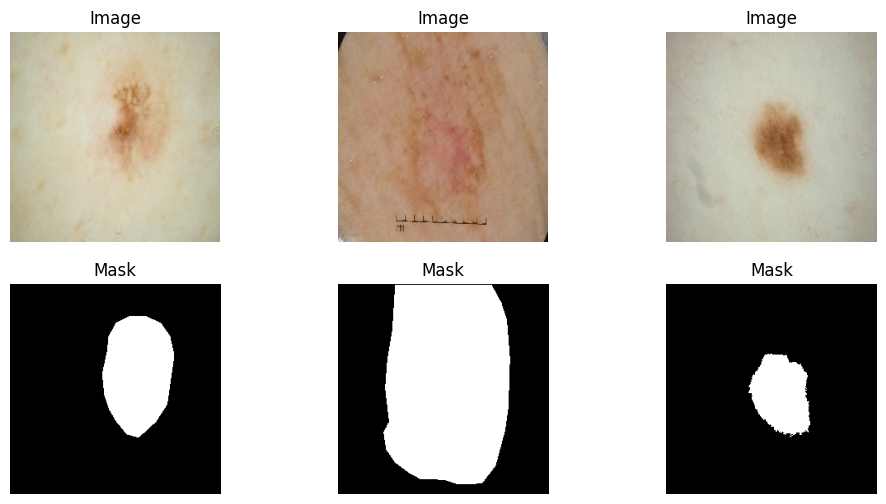

In [44]:
# ============================================================
# VISUALIZE TRAINING SAMPLES
# ============================================================

for images, masks in train_dataset.take(1):

    plt.figure(figsize=(12, 6))

    for i in range(3):

        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
        plt.title("Image")

        plt.subplot(2, 3, i + 4)
        plt.imshow(
            tf.squeeze(masks[i]),
            cmap="gray"
        )
        plt.axis("off")
        plt.title("Mask")

    plt.show()

## U-NET+SIMAM MODEL

In [45]:
# ============================================================
# Convolution Block
# ============================================================

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Activation("relu")(x)

    return x

In [46]:
# ============================================================
# SimAM Attention Block (Keras 3 Compatible)
# ============================================================

def simam_block(x, lambda_val=1e-4):

    mean = layers.Lambda(
        lambda z: tf.reduce_mean(
            z,
            axis=[1, 2],
            keepdims=True
        )
    )(x)

    diff = layers.Subtract()([x, mean])

    sq_diff = layers.Multiply()([diff, diff])

    var = layers.Lambda(
        lambda z: tf.reduce_mean(
            z,
            axis=[1, 2],
            keepdims=True
        )
    )(sq_diff)

    denom = layers.Lambda(
        lambda z: 4.0 * (z + lambda_val)
    )(var)

    e_inv = layers.Lambda(
        lambda t: (t[0] / t[1]) + 0.5
    )([sq_diff, denom])

    attention = layers.Activation(
        "sigmoid"
    )(e_inv)

    out = layers.Multiply()(
        [x, attention]
    )

    return out

In [47]:
# ============================================================
# Encoder Block
# ============================================================

def encoder_block(inputs, filters):

    x = conv_block(
        inputs,
        filters
    )

    x = simam_block(x)

    p = layers.MaxPooling2D(
        (2, 2)
    )(x)

    return x, p

In [48]:
# ============================================================
# Decoder Block
# ============================================================

def decoder_block(
    inputs,
    skip_features,
    filters
):

    x = layers.Conv2DTranspose(
        filters,
        (2, 2),
        strides=2,
        padding="same"
    )(inputs)

    x = layers.Concatenate()(
        [x, skip_features]
    )

    x = conv_block(
        x,
        filters
    )

    return x

In [51]:
# ============================================================
# Build U-Net + SimAM
# ============================================================

def build_unet_simam(
    input_shape=(256, 256, 3)
):

    inputs = layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)

    b1 = simam_block(b1)

    d1 = decoder_block(
        b1,
        s4,
        512
    )

    d2 = decoder_block(
        d1,
        s3,
        256
    )

    d3 = decoder_block(
        d2,
        s2,
        128
    )

    d4 = decoder_block(
        d3,
        s1,
        64
    )

    outputs = layers.Conv2D(
        1,
        1,
        activation="sigmoid"
    )(d4)

    model = tf.keras.Model(
    inputs,
    outputs
)

    return model

In [52]:
# ============================================================
# Create Model
# ============================================================

model = build_unet_simam()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_48       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 256, 256,  │     36,928 │ activation_48[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_49       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_40 (Lambda)  │ (None, 1, 1, 64)  │          0 │ activation_49[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_10         │ (None, 256, 256,  │          0 │ activation_49[0]… │
│ (Subtract)          │ 64)               │            │ lambda_40[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_20         │ (None, 256, 256,  │          0 │ subtract_10[0][0… │
│ (Multiply)          │ 64)               │            │ subtract_10[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_41 (Lambda)  │ (None, 1, 1, 64)  │          0 │ multiply_20[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_42 (Lambda)  │ (None, 1, 1, 64)  │          0 │ lambda_41[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_43 (Lambda)  │ (None, 256, 256,  │          0 │ multiply_20[0][0… │
│                     │ 64)               │            │ lambda_42[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_50       │ (None, 256, 256,  │          0 │ lambda_43[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_21         │ (None, 256, 256,  │          0 │ activation_49[0]… │
│ (Multiply)          │ 64)               │            │ activation_50[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ multiply_21[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_42[0][0] 

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [53]:
# ============================================================
# DICE METRIC
# ============================================================

def dice_coef(y_true, y_pred):

    smooth = 1e-7

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    return (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        + smooth
    )

# ============================================================
# IOU METRIC
# ============================================================

def iou(y_true, y_pred):

    smooth = 1e-7

    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    union = (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        - intersection
    )

    return (
        intersection + smooth
    ) / (
        union + smooth
    )

In [54]:
# ============================================================
# DICE LOSS
# ============================================================

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# ============================================================
# BCE + DICE LOSS
# ============================================================

def bce_dice_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    dice = dice_loss(
        y_true,
        y_pred
    )

    return bce + dice



In [55]:
# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LR
    ),
    loss=bce_dice_loss,
    metrics=[
        dice_coef,
        iou
    ]
)

In [56]:
# ============================================================
# CALLBACKS
# ============================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_unet_simam.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

In [57]:
# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40


2026-08-02 05:20:08.740403: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv (f32[16,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-08-02 05:20:08.846734: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.106460828s
Trying algorithm eng12{k11=2} for conv (f32[16,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

129/130 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - dice_coef: 0.5405 - iou: 0.3821 - loss: 0.8676

2026-08-02 05:23:51.929602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 05:23:52.170448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 05:23:54.107932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 05:23:54.430949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 05:24:08.739389: E external/local_xla/xla/stream_

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.5412 - iou: 0.3828 - loss: 0.8661   

2026-08-02 05:25:15.912824: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 05:25:16.143141: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 05:25:17.094427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 05:25:17.403784: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 05:25:24.974627: E external/local_xla/xla/stream_


Epoch 1: val_dice_coef improved from None to 0.22782, saving model to best_unet_simam.keras

Epoch 1: finished saving model to best_unet_simam.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - dice_coef: 0.6343 - iou: 0.4741 - loss: 0.6724 - val_dice_coef: 0.2278 - val_iou: 0.1287 - val_loss: 1.2875 - learning_rate: 1.0000e-04
Epoch 2/40
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - dice_coef: 0.7362 - iou: 0.5848 - loss: 0.4719
Epoch 2: val_dice_coef improved from 0.22782 to 0.58031, saving model to best_unet_simam.keras

Epoch 2: finished saving model to best_unet_simam.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - dice_coef: 0.7482 - iou: 0.6006 - loss: 0.4554 - val_dice_coef: 0.5803 - val_iou: 0.4111 - val_loss: 0.7615 - learning_rate: 1.0000e-04
Epoch 3/40
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - dice_coef: 0.7728 - iou: 0.6318 - loss: 0.4065
Epoch 3: val_dice_coef improved from 0.58031 to 0.69727, saving model to best_unet_simam.keras

Epoch 3: finished saving model to be

In [59]:
results = model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test Loss : {results[0]:.4f}")
print(f"Test Dice : {results[1]:.4f}")
print(f"Test IoU  : {results[2]:.4f}")

16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - dice_coef: 0.8798 - iou: 0.7859 - loss: 0.2674

2026-08-02 06:39:54.248475: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 06:39:54.476196: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 06:39:55.560695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 06:39:55.867858: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 06:40:03.947656: E external/local_xla/xla/stream_

17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - dice_coef: 0.8778 - iou: 0.7830 - loss: 0.2906
Test Loss : 0.2906
Test Dice : 0.8778
Test IoU  : 0.7830


The SimAM-enhanced U-Net achieved the best overall segmentation performance on the ISIC 2018 Task 1 dataset. The model obtained a Dice coefficient of 0.8778 and an IoU score of 0.7830, outperforming both the baseline U-Net and the CBAM-enhanced U-Net. Since SimAM is a parameter-free attention mechanism, these improvements were achieved without increasing the model size or trainable parameter count. The results indicate that SimAM effectively enhances feature representation and lesion localization while maintaining computational efficiency.